# Model Training, Tuning & Over-fitting Control

*Companion notebook — the scripts in `src/` are the source of truth; this notebook loads and displays their outputs.*

In [1]:
import os, sys, warnings; warnings.filterwarnings('ignore')
sys.path.insert(0, os.path.abspath('..')); os.environ['TF_CPP_MIN_LOG_LEVEL']='3'
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown
from config import *


## 1. Walk-forward hyper-parameter search
`python src/training/tune_models.py` — expanding-window folds on train+val only. Best parameters per asset/model:

In [2]:
import json; print(json.dumps(json.load(open(BEST_PARAMS_PATH)), indent=1))

{
 "return_1d": {
  "Bitcoin": {
   "Ridge": {
    "alpha": 100.0
   },
   "RandomForest": {
    "n_estimators": 300,
    "max_depth": 3,
    "min_samples_leaf": 30
   },
   "LightGBM": {
    "n_estimators": 600,
    "learning_rate": 0.03,
    "num_leaves": 31,
    "min_child_samples": 20,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_lambda": 0.0
   },
   "CatBoost": {
    "iterations": 800,
    "learning_rate": 0.03,
    "depth": 7,
    "l2_leaf_reg": 3.0
   },
   "GRU": {
    "units": 32,
    "dropout": 0.4,
    "learning_rate": 0.001,
    "batch_size": 64,
    "epochs": 40,
    "patience": 6
   },
   "LSTM": {
    "units": 32,
    "dropout": 0.4,
    "learning_rate": 0.001,
    "batch_size": 64,
    "epochs": 40,
    "patience": 6
   }
  },
  "Gold": {
   "Ridge": {
    "alpha": 100.0
   },
   "RandomForest": {
    "n_estimators": 300,
    "max_depth": 3,
    "min_samples_leaf": 30
   },
   "LightGBM": {
    "n_estimators": 600,
    "learning_rate": 0.01,
    "num_lea

In [3]:
pd.read_csv(os.path.join(TUNING_DIR, 'tuning_summary.csv')).round(5)

,asset,model,RMSE_ret_mean,RMSE_ret_std,MAE_ret_mean,MAE_ret_std,R2_ret_mean,R2_ret_std,RMSE_usd_mean,RMSE_usd_std,DirAcc_pct_mean,DirAcc_pct_std,best_params
0,Bitcoin,Ridge,0.03161,0.00693,0.02135,0.00414,-0.00507,0.00283,1430.33747,435.81126,49.35567,1.89929,"{""alpha"": 100.0}"
1,Bitcoin,RandomForest,0.03160,0.00688,0.02140,0.00416,-0.00536,0.00555,1432.90172,433.81705,49.95704,2.40051,"{""n_estimators"": 300, ""max_depth"": 3, ""min_sam..."
2,Bitcoin,LightGBM,0.03158,0.00692,0.02140,0.00420,-0.00344,0.00412,1430.51610,432.69011,51.15979,1.73690,"{""n_estimators"": 600, ""learning_rate"": 0.03, ""..."
3,Bitcoin,CatBoost,0.03156,0.00695,0.02136,0.00415,-0.00131,0.00570,1427.06617,434.17045,50.21478,2.31601,"{""iterations"": 800, ""learning_rate"": 0.03, ""de..."
4,Bitcoin,GRU,0.03168,0.00697,0.02136,0.00418,-0.00897,0.00479,1432.61201,435.63222,49.39863,0.98329,"{""units"": 32, ""dropout"": 0.4, ""learning_rate"":..."
5,Bitcoin,LSTM,0.03170,0.00697,0.02142,0.00424,-0.01027,0.00503,1433.09348,436.33228,48.79725,0.70844,"{""units"": 32, ""dropout"": 0.4, ""learning_rate"":..."
6,Gold,Ridge,0.01112,0.00223,0.00787,0.00128,-0.00314,0.00272,28.39703,16.76047,54.75527,1.97818,"{""alpha"": 100.0}"
7,Gold,RandomForest,0.01116,0.00220,0.00791,0.00124,-0.01167,0.01778,28.45450,16.70667,51.89409,3.07520,"{""n_estimators"": 300, ""max_depth"": 3, ""min_sam..."
8,Gold,LightGBM,0.01113,0.00223,0.00787,0.00127,-0.00449,0.00352,28.42293,16.78590,55.76569,2.88126,"{""n_estimators"": 600, ""learning_rate"": 0.01, ""..."
9,Gold,CatBoost,0.01110,0.00219,0.00786,0.00126,-0.00074,0.00469,28.28806,16.54601,54.81937,1.68996,"{""iterations"": 800, ""learning_rate"": 0.01, ""de..."


## 2. Train vs validation performance (phase A of `train_models.py`)

In [4]:
tv = pd.read_csv(os.path.join(RESULTS_DIR, 'train_val_metrics.csv'))
tv.pivot_table(index=['asset','model'], columns='split', values='RMSE_ret').round(5)

split                   train      val
asset   model                         
Bitcoin CatBoost      0.03209  0.02604
        GRU           0.03361  0.02597
        LSTM          0.03358  0.02617
        LightGBM      0.02740  0.02539
        RandomForest  0.03299  0.02610
        Ridge         0.03352  0.02605
Gold    CatBoost      0.00932  0.01995
        GRU           0.00974  0.02022
        LSTM          0.00975  0.02028
        LightGBM      0.00973  0.02028
        RandomForest  0.00953  0.02031
        Ridge         0.00973  0.02025
Silver  CatBoost      0.01904  0.05528
        GRU           0.01917  0.05528
        LSTM          0.01920  0.05543
        LightGBM      0.01919  0.05532
        RandomForest  0.01867  0.05541
        Ridge         0.01915  0.05543

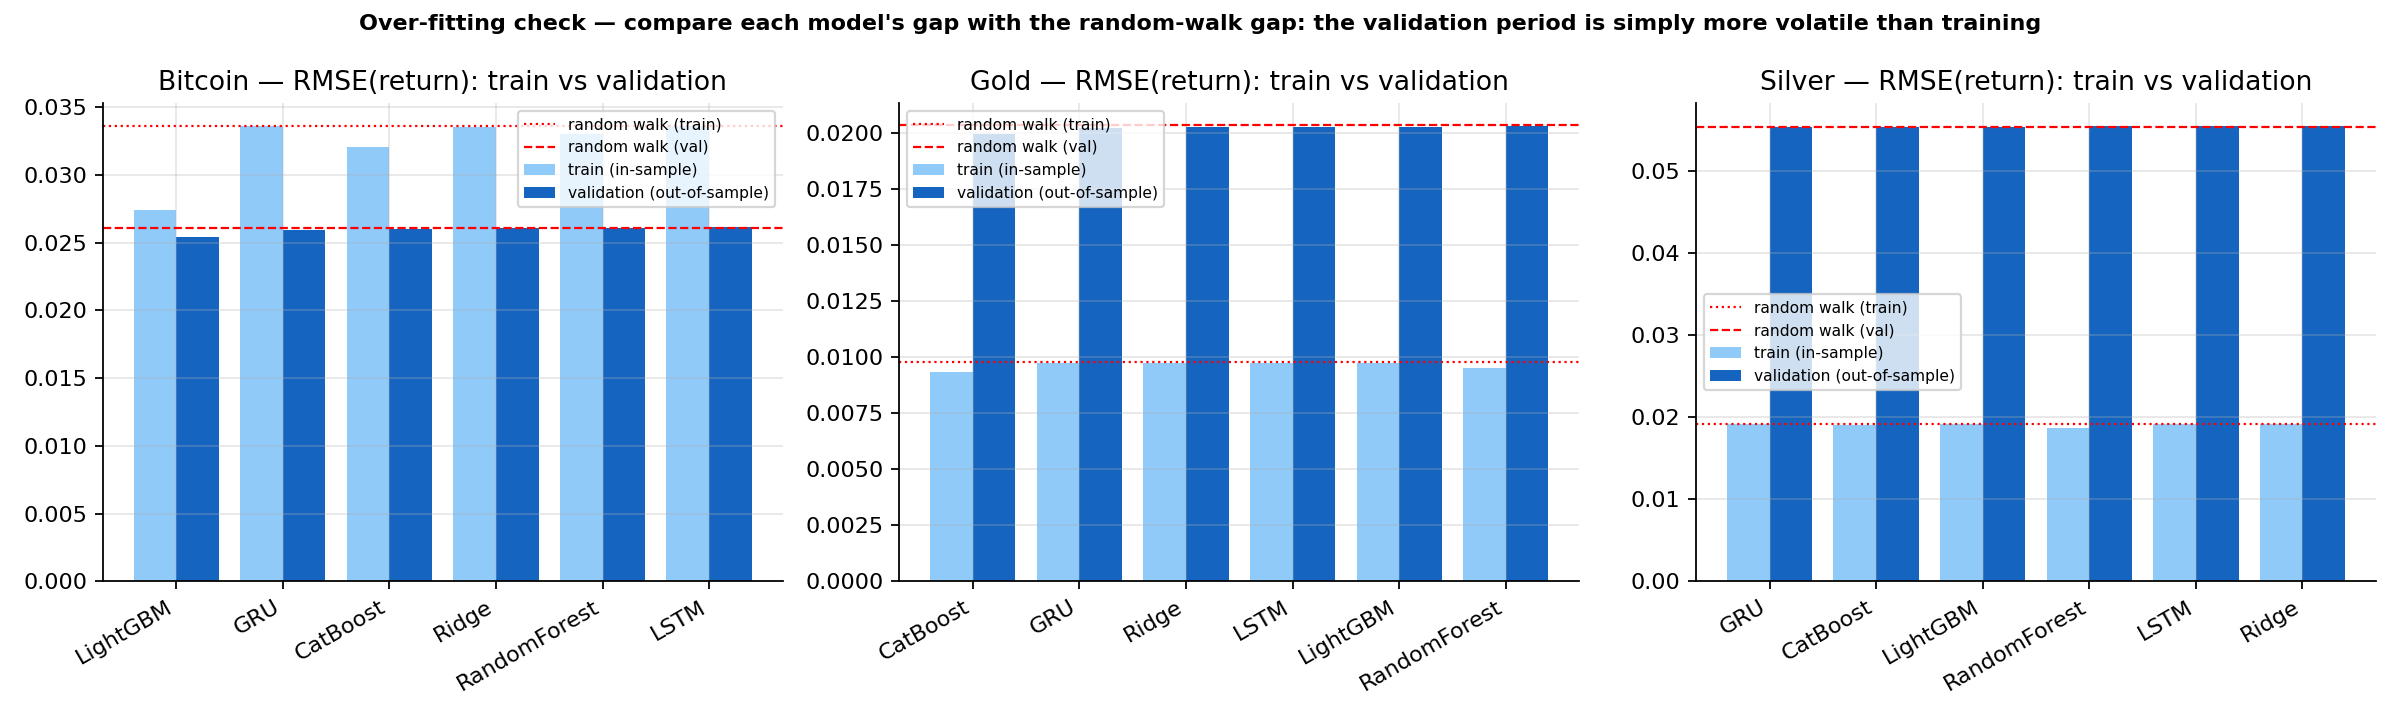

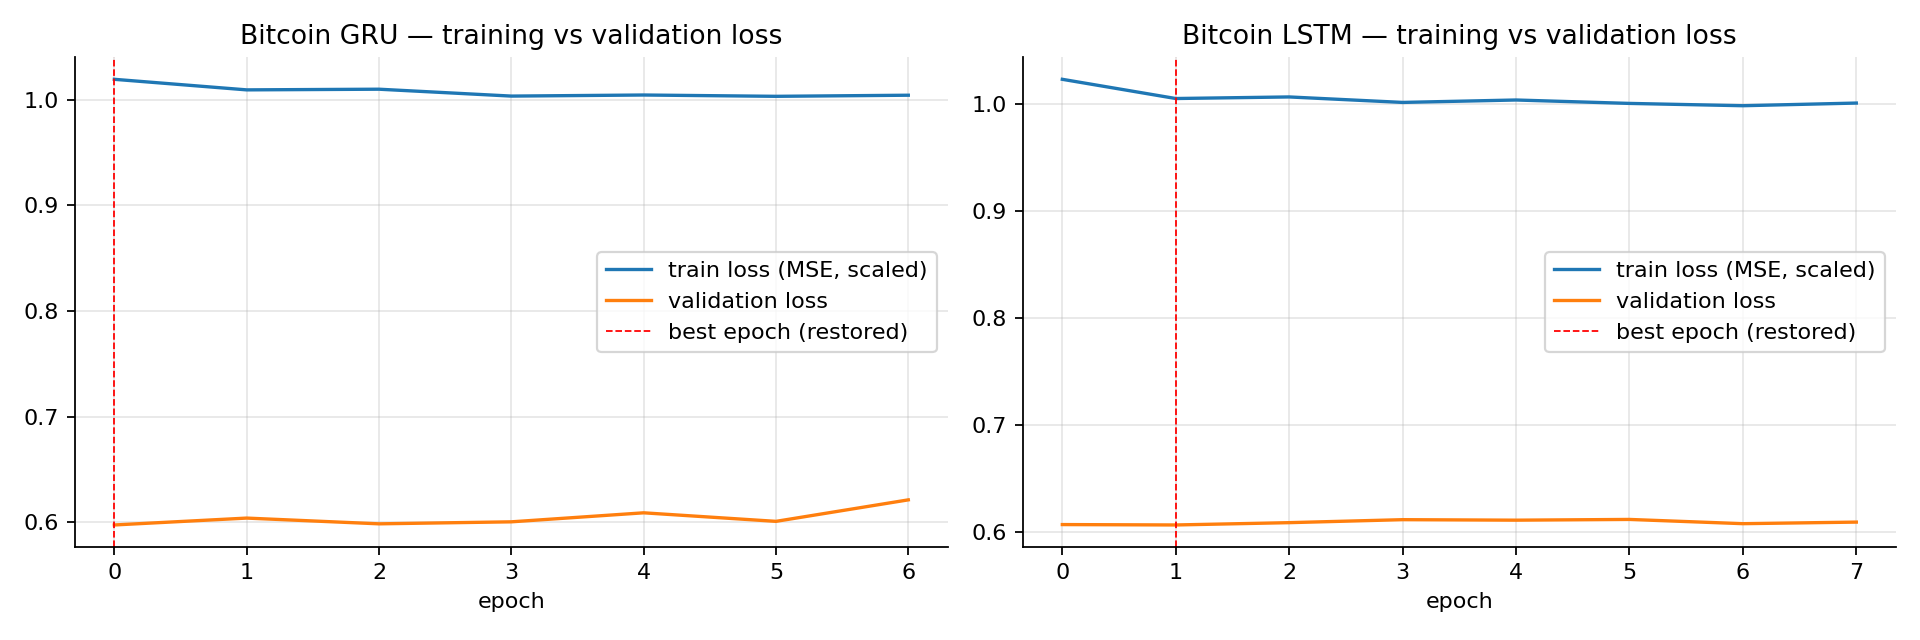

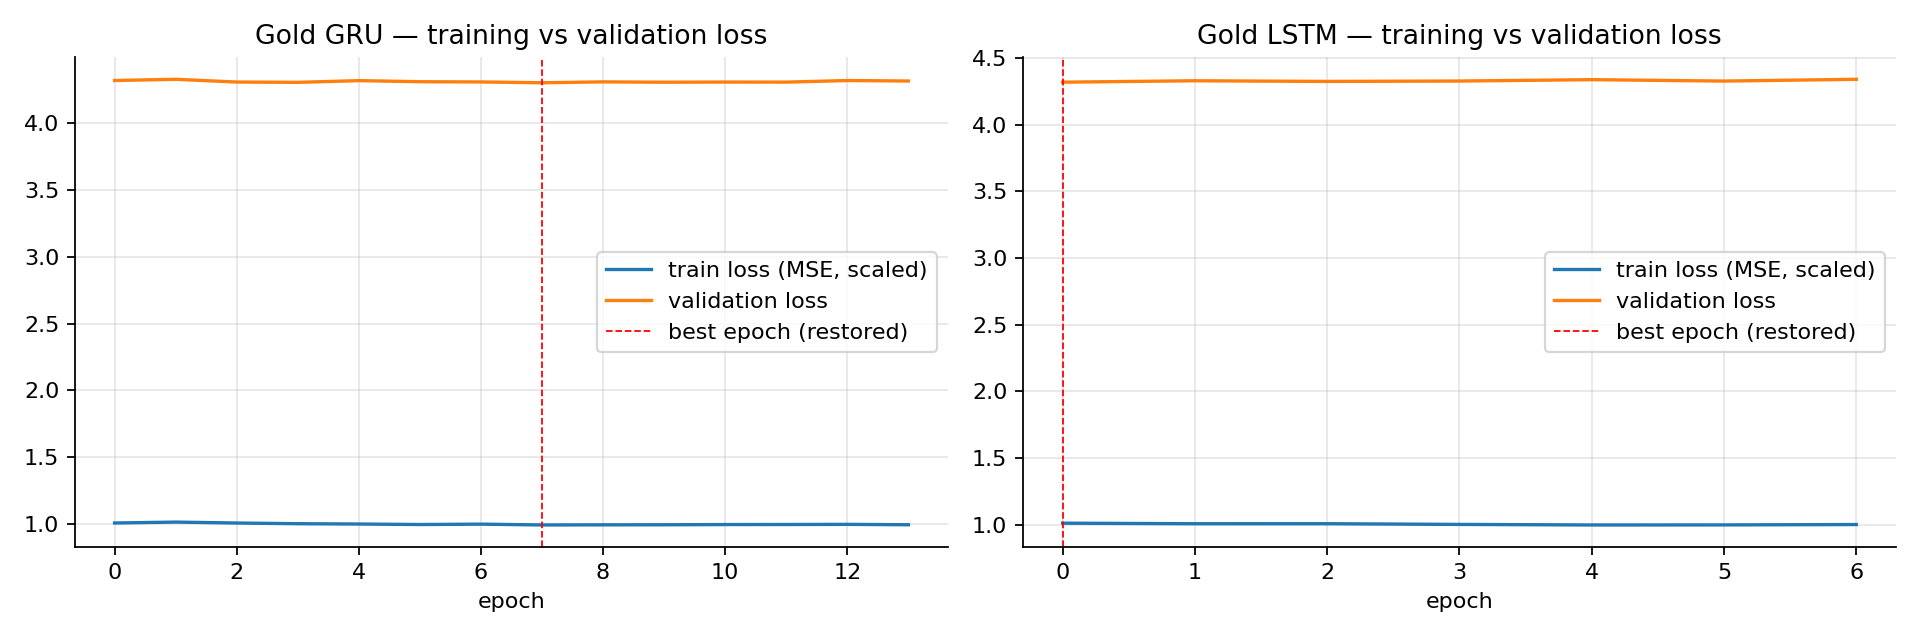

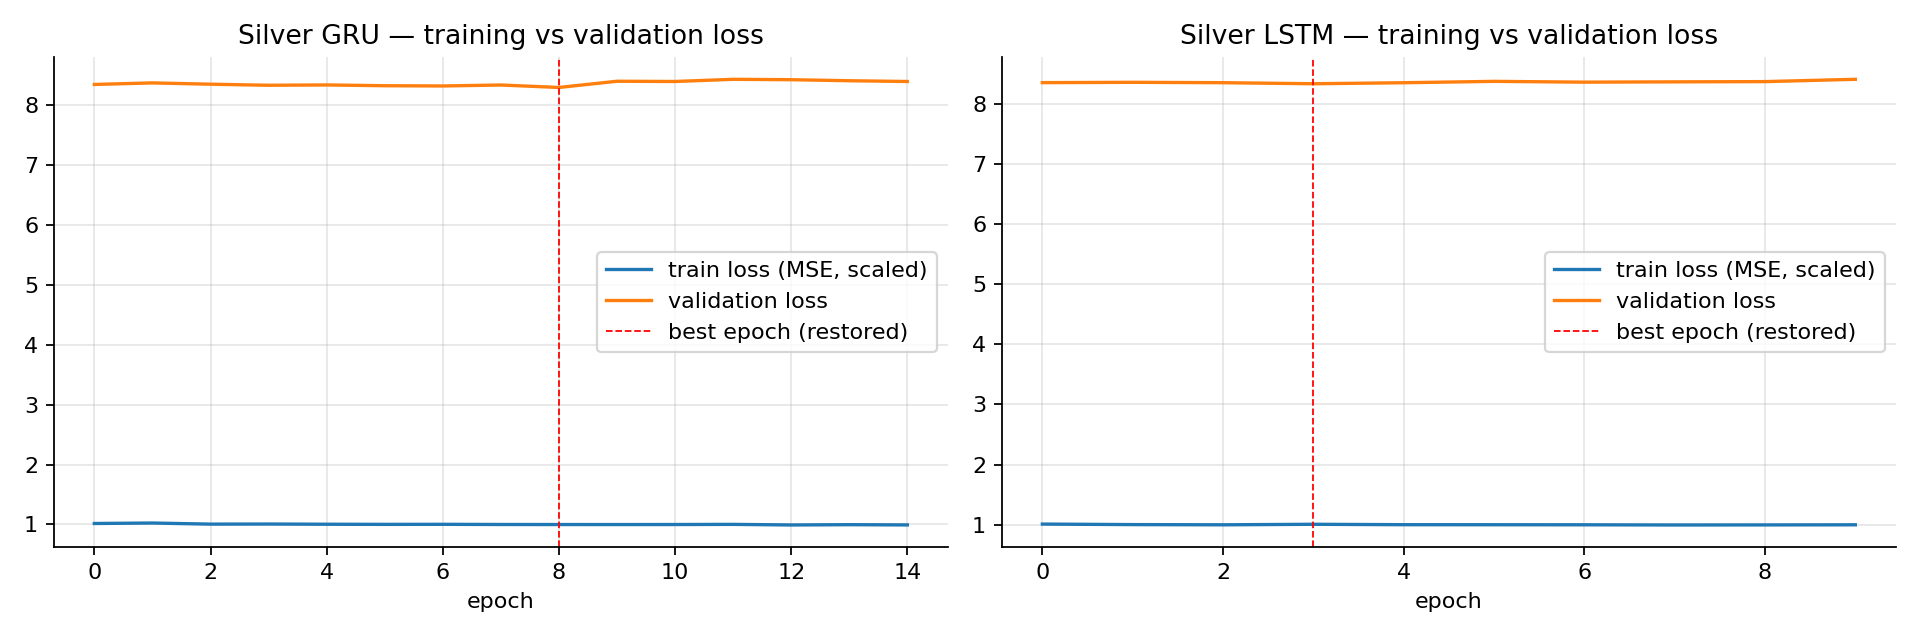

In [5]:
display(Image(os.path.join(FIGURES_DIR, 'overfitting_gap.png')))
for a in ASSETS:
    p = os.path.join(FIGURES_DIR, f'{get_prefix(a)}_loss_curves.png')
    if os.path.exists(p): display(Image(p))

## 3. Model architectures

In [6]:
from src.models.model_gru import build_gru_model
from src.data.preprocessing import build_dataset
n_features = len(build_dataset('Bitcoin')['columns'])
build_gru_model(SEQ_LEN, n_features, units=32).summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 32)             │         6,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,593 (25.75 KB)

 Trainable params: 6,593 (25.75 KB)

 Non-trainable params: 0 (0.00 B)